# 1. Perkenalan Dataset

Dataset: Telco Customer Churn (Kaggle)

- Sumber: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
- Tujuan: Memprediksi apakah pelanggan akan churn (`Yes`) atau tidak (`No`).
- Tipe: Tabular, klasifikasi biner.
- Jumlah fitur: fitur demografis (gender, SeniorCitizen, Partner, Dependents), layanan (PhoneService, InternetService, dll.), dan pembayaran (Contract, PaymentMethod, MonthlyCharges, TotalCharges).
- Target: `Churn`.


In [14]:
# 2. Import Library

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [15]:
# 3. Memuat Dataset

file_path = "namadataset_raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(file_path)
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
df.shape, df.dtypes.head()


((7043, 21),
 customerID       object
 gender           object
 SeniorCitizen     int64
 Partner          object
 Dependents       object
 dtype: object)

In [17]:
# 4. Exploratory Data Analysis (EDA)

# Info struktur data
df.info()

# Statistik numerik
df.describe()

# Distribusi target
df["Churn"].value_counts(normalize=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

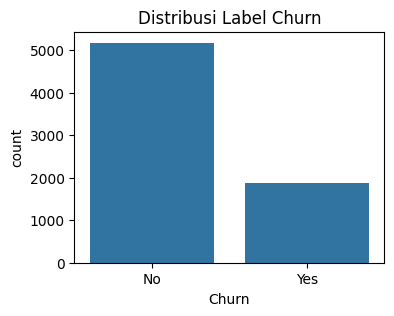

In [18]:
plt.figure(figsize=(4,3))
sns.countplot(x="Churn", data=df)
plt.title("Distribusi Label Churn")
plt.show()


In [19]:
# 5. Data Preprocessing

# 1. Tangani missing values
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# 2. Pisah fitur dan target
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"].map({"No": 0, "Yes": 1})  # ubah ke 0/1

# 3. Tentukan kolom numerik dan kategorikal
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "bool"]).columns.tolist()

numeric_features, categorical_features


C:\Users\BONO DIGITAL STUDIO\AppData\Local\Temp\ipykernel_15980\1507397437.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'],
 ['gender',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod'])

In [20]:
# 4. Pipeline preprocessing

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# 5. Split train-test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((5634, 19), (1409, 19))

In [21]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed.shape, X_test_processed.shape


((5634, 45), (1409, 45))

In [22]:
# 6. Preprocessing lengkap dengan pipeline

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identifikasi kolom numerik dan kategorikal
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "bool"]).columns.tolist()

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)


Numeric: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [23]:
# Buat preprocessor
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore", drop="first")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# Fit dan transform
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Shape setelah preprocessing:")
print("X_train:", X_train_processed.shape)
print("X_test:", X_test_processed.shape)


Shape setelah preprocessing:
X_train: (5634, 30)
X_test: (1409, 30)


In [26]:
import joblib

# Simpan preprocessor
joblib.dump(preprocessor, "preprocessing/namadataset_preprocessing/preprocessor.pkl")

# Buat DataFrame untuk X_train_processed dan X_test_processed
# (karena hasil ColumnTransformer bisa jadi sparse matrix)

# Cek apakah sparse
print("X_train_processed type:", type(X_train_processed))
print("X_train_processed shape:", X_train_processed.shape)

if hasattr(X_train_processed, "toarray"):
    # Kalau sparse matrix, convert ke dense
    X_train_dense = pd.DataFrame(X_train_processed.toarray())
    X_test_dense = pd.DataFrame(X_test_processed.toarray())
else:
    X_train_dense = pd.DataFrame(X_train_processed)
    X_test_dense = pd.DataFrame(X_test_processed)

# Simpan sebagai CSV (aman, tidak ada pickle issue)
X_train_dense.to_csv("preprocessing/namadataset_preprocessing/X_train_processed.csv", index=False)
X_test_dense.to_csv("preprocessing/namadataset_preprocessing/X_test_processed.csv", index=False)
pd.Series(y_train).to_csv("preprocessing/namadataset_preprocessing/y_train.csv", index=False)
pd.Series(y_test).to_csv("preprocessing/namadataset_preprocessing/y_test.csv", index=False)

print("✅ Preprocessing artifacts re-saved as CSV!")


X_train_processed type: <class 'numpy.ndarray'>
X_train_processed shape: (5634, 30)
✅ Preprocessing artifacts re-saved as CSV!


In [28]:
# Di akhir notebook, tambah cell ini:
import mlflow.sklearn
from sklearn.ensemble import RandomForestClassifier
import joblib

# Train model untuk serving
model_serve = RandomForestClassifier(n_estimators=100, random_state=42)
model_serve.fit(X_train_processed, y_train)

# Save sebagai MLflow model
mlflow.sklearn.save_model(
    sk_model=model_serve,
    path="../Membangun_model/local_model_serve",
    input_example=X_test_processed[:1],  # contoh input
    conda_env=None
)

print("✅ Model saved to ../Membangun_model/local_model_serve/")


✅ Model saved to ../Membangun_model/local_model_serve/
